# Salary Prediction ML Pipeline

**Stack:** `pandas` · `scikit-learn` · `skrub` · `matplotlib`

This notebook builds a machine-learning pipeline that predicts annual employee salaries from job-related features.
The goal is to demonstrate a workflow using [**skrub**](https://skrub-data.org/), a modern library that makes machine learning on messy tabular dataframes almost effortless.

**What you'll see in this notebook:**
1. Data loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing with `skrub.TableVectorizer`
4. Train / test split
5. Building two models with `skrub.tabular_pipeline`
6. Evaluation (MAE, RMSE, R²) and cross-validation
7. Visual diagnostics (predictions vs. actuals, residuals)
8. Conclusions and possible improvements

> *The dataset is a synthetic but realistic public-sector salary dataset, generated by `src/generate_data.py`. The schema is inspired by the Montgomery County, MD open salary records used in the official skrub documentation.*


## 1. Imports and configuration

We import everything up-front and fix a random seed so results are reproducible.

In [1]:
# --- Standard data / ML stack ---
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- scikit-learn ---
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor

# --- skrub: tabular preprocessing & pipelines ---
import skrub
from skrub import TableVectorizer, tabular_pipeline

# --- Reproducibility & cosmetics ---
warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")

print("skrub version:", skrub.__version__)

skrub version: 0.9.0


## 2. Loading the dataset

The dataset contains one row per employee with categorical features (department, job title, etc.), a hire date and the target variable `current_annual_salary`.

If `data/employee_salaries.csv` does not exist yet, run `python src/generate_data.py` once from the project root.

In [2]:
DATA_PATH = "../data/employee_salaries.csv"
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 9,500 rows × 9 columns


,gender,department,department_name,division,assignment_category,employee_position_title,date_first_hired,year_first_hired,current_annual_salary
0,M,POL,Department of Police,POL Division 4,Fulltime-Regular,Permit Technician,09/06/1988,1988,78303.83
1,M,POL,Department of Police,POL Division 5,Fulltime-Regular,Liquor Store Clerk II,11/13/1989,1989,65293.29
2,M,FRS,Fire and Rescue Services,FRS Division 6,Fulltime-Regular,Administrative Specialist II,06/13/2005,2005,81971.28
3,F,HHS,Department of Health and Human Services,HHS Division 3,Fulltime-Regular,Senior Engineer,02/21/2009,2009,120664.72
4,F,POL,Department of Police,POL Division 8,Fulltime-Regular,Planning Specialist III,03/10/2013,2013,105395.40


## 3. Exploratory Data Analysis

Before modeling, we quickly look at the data: types, missing values, target distribution, and a couple of obvious relationships.

In [3]:
print("Column dtypes:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nTarget summary statistics:")
df["current_annual_salary"].describe().round(2)

Column dtypes:
gender                         str
department                     str
department_name                str
division                       str
assignment_category            str
employee_position_title        str
date_first_hired               str
year_first_hired             int64
current_annual_salary      float64
dtype: object

Missing values per column:
gender                     151
department                   0
department_name              0
division                    49
assignment_category          0
employee_position_title      0
date_first_hired             0
year_first_hired             0
current_annual_salary        0
dtype: int64

Target summary statistics:


count      9500.00
mean      86848.31
std       29397.87
min       25000.00
25%       65176.87
50%       83467.56
75%      106867.27
max      210053.07
Name: current_annual_salary, dtype: float64

### 3.1 Distribution of salaries

Salary distributions are typically right-skewed — a long tail of high earners. This is a useful thing to know, because some models (linear ones especially) work better when the target is closer to normal.

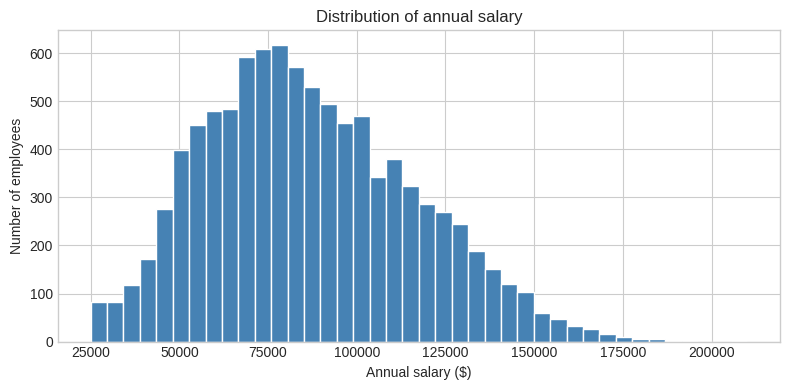

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["current_annual_salary"], bins=40, color="steelblue", edgecolor="white")
ax.set_title("Distribution of annual salary")
ax.set_xlabel("Annual salary ($)")
ax.set_ylabel("Number of employees")
plt.tight_layout()
plt.show()

### 3.2 Average salary by department

Some departments (Police, Fire, Engineering-heavy ones) pay more on average than others (Libraries, Liquor Control). The model should capture this.

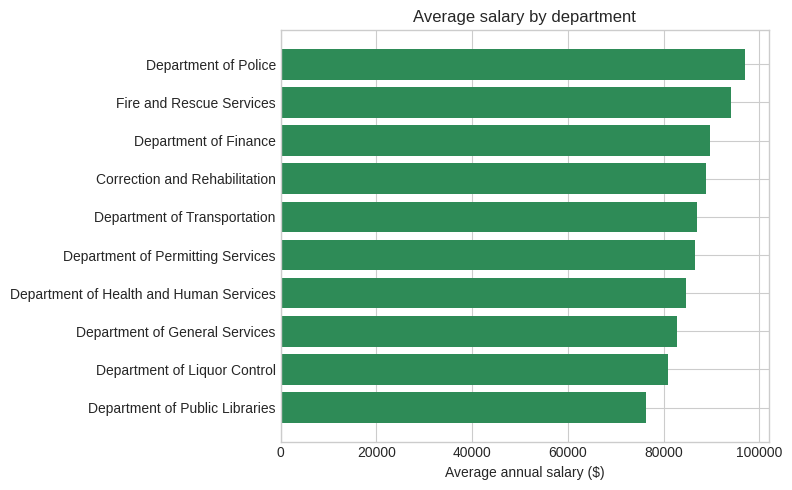

In [5]:
mean_by_dept = (
    df.groupby("department_name")["current_annual_salary"]
      .mean()
      .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mean_by_dept.index, mean_by_dept.values, color="seagreen")
ax.set_title("Average salary by department")
ax.set_xlabel("Average annual salary ($)")
plt.tight_layout()
plt.show()

### 3.3 Salary vs. tenure

We compute `tenure_years = 2024 − year_first_hired` to get a feel for how experience relates to pay. The relationship looks positive, as expected, but quite noisy.

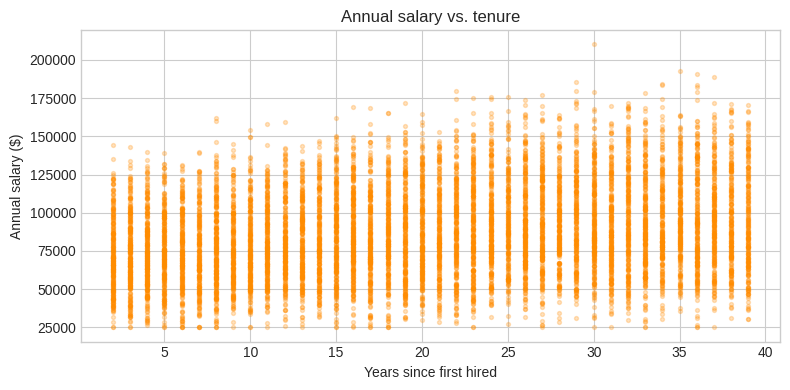

In [6]:
df_eda = df.copy()
df_eda["tenure_years"] = 2024 - df_eda["year_first_hired"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df_eda["tenure_years"], df_eda["current_annual_salary"],
           s=8, alpha=0.25, color="darkorange")
ax.set_title("Annual salary vs. tenure")
ax.set_xlabel("Years since first hired")
ax.set_ylabel("Annual salary ($)")
plt.tight_layout()
plt.show()

## 4. Feature / target split

We separate the target (`current_annual_salary`) from the features. Notice we keep the raw `date_first_hired` string and the high-cardinality `employee_position_title` — skrub will handle them automatically.

In [7]:
y = df["current_annual_salary"]
X = df.drop(columns=["current_annual_salary"])

print("X shape:", X.shape, "| y shape:", y.shape)
X.head(3)

X shape: (9500, 8) | y shape: (9500,)


,gender,department,department_name,division,assignment_category,employee_position_title,date_first_hired,year_first_hired
0,M,POL,Department of Police,POL Division 4,Fulltime-Regular,Permit Technician,09/06/1988,1988
1,M,POL,Department of Police,POL Division 5,Fulltime-Regular,Liquor Store Clerk II,11/13/1989,1989
2,M,FRS,Fire and Rescue Services,FRS Division 6,Fulltime-Regular,Administrative Specialist II,06/13/2005,2005


## 5. Preprocessing with `skrub.TableVectorizer`

### Why skrub?
Real tabular data rarely arrives in a model-ready form: there are mixed types, missing values, high-cardinality categories, dates as strings, etc. With plain scikit-learn this means manually wiring up `ColumnTransformer`, `OneHotEncoder`, `OrdinalEncoder`, date parsers and imputers — which is error-prone and verbose.

`TableVectorizer` is skrub's drop-in solution: it inspects each column, picks an appropriate encoder automatically, and produces a numeric matrix ready for any scikit-learn estimator.

Below we just *peek* at what the vectorizer produces on the first 1000 rows.

In [8]:
vectorizer = TableVectorizer()
X_vec_preview = vectorizer.fit_transform(X.head(1000))

print("Original shape:", X.head(1000).shape)
print("Vectorized shape:", X_vec_preview.shape)
print("First 6 generated feature columns:")
list(X_vec_preview.columns)[:6]

Original shape: (1000, 8)
Vectorized shape: (1000, 79)
First 6 generated feature columns:


['gender_F',
 'gender_M',
 'gender_nan',
 'department_COR',
 'department_DOT',
 'department_FIN']

## 6. Train / test split

A standard 80/20 split with a fixed random seed for reproducibility.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " | Test:", X_test.shape)

Train: (7600, 8)  | Test: (1900, 8)


## 7. Model training

We build two pipelines using `skrub.tabular_pipeline`. This helper takes a scikit-learn estimator and automatically prepends the right preprocessing for it (different encoders are chosen for linear vs. tree-based models — that's the magic).

### Model 1 — Ridge regression
A regularized linear baseline. skrub will scale numeric features and one-hot encode the categoricals because the estimator is linear.

In [10]:
ridge_pipe = tabular_pipeline(Ridge(alpha=1.0, random_state=RANDOM_STATE))
ridge_pipe.fit(X_train, y_train)
print("Ridge pipeline trained.")

Ridge pipeline trained.


### Model 2 — Histogram Gradient Boosting
A strong, fast tree-based model that handles nonlinearity and feature interactions natively. For tree models, skrub uses ordinal-style encoders that are more efficient than one-hot.

In [11]:
hgb_pipe = tabular_pipeline(
    HistGradientBoostingRegressor(random_state=RANDOM_STATE)
)
hgb_pipe.fit(X_train, y_train)
print("HistGradientBoosting pipeline trained.")

HistGradientBoosting pipeline trained.


## 8. Evaluation

We compare both models on three standard regression metrics:
- **MAE** — mean absolute error (in dollars), easy to interpret.
- **RMSE** — root mean squared error, penalizes large errors more.
- **R²** — proportion of variance explained (1.0 = perfect).

In [12]:
def evaluate(name, model, X_te, y_te):
    pred = model.predict(X_te)
    return {
        "model": name,
        "MAE":   mean_absolute_error(y_te, pred),
        "RMSE":  root_mean_squared_error(y_te, pred),
        "R²":    r2_score(y_te, pred),
    }

results = pd.DataFrame([
    evaluate("Ridge",                 ridge_pipe, X_test, y_test),
    evaluate("HistGradientBoosting",  hgb_pipe,   X_test, y_test),
]).round(3)
results

,model,MAE,RMSE,R²
0,Ridge,7507.797,10008.007,0.883
1,HistGradientBoosting,7002.917,9244.871,0.900


### 8.1 Cross-validation
A single train/test split can be lucky or unlucky. 5-fold cross-validation gives a more reliable estimate of generalization performance for the better-performing model.

In [13]:
cv_scores = cross_val_score(hgb_pipe, X, y, cv=5, scoring="r2")
print("HistGradientBoosting 5-fold CV R² scores:", cv_scores.round(3))
print(f"Mean R²: {cv_scores.mean():.3f}  (± {cv_scores.std():.3f})")

HistGradientBoosting 5-fold CV R² scores: [0.91  0.909 0.909 0.901 0.91 ]
Mean R²: 0.908  (± 0.003)


## 9. Visual diagnostics

### 9.1 Predicted vs. actual salaries
The closer the points lie to the diagonal red line, the better the predictions.

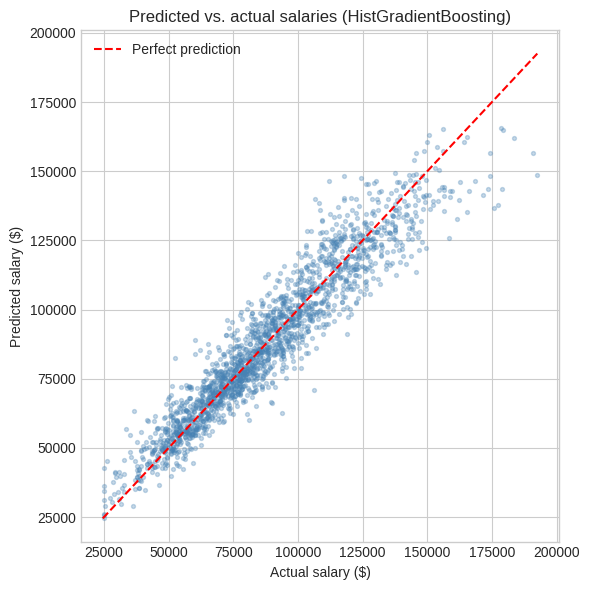

In [14]:
preds = hgb_pipe.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds, s=8, alpha=0.3, color="steelblue")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Actual salary ($)")
ax.set_ylabel("Predicted salary ($)")
ax.set_title("Predicted vs. actual salaries (HistGradientBoosting)")
ax.legend()
plt.tight_layout()
plt.show()

### 9.2 Distribution of residuals
A good model should produce residuals that are roughly centered on zero and symmetric. Heavy tails or strong asymmetry can hint at missing features.

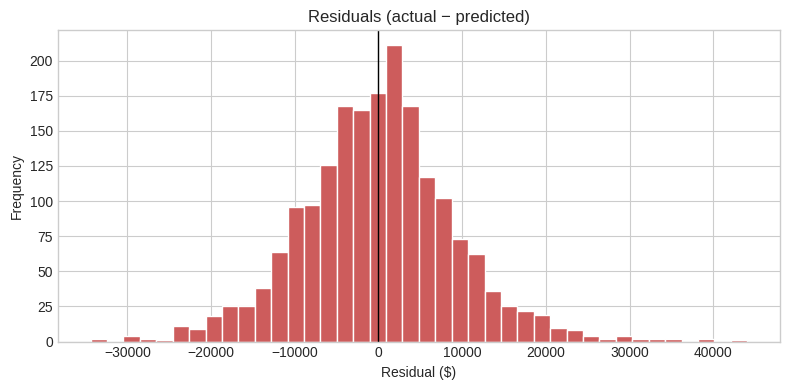

In [15]:
residuals = y_test - preds

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=40, color="indianred", edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.set_title("Residuals (actual − predicted)")
ax.set_xlabel("Residual ($)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 10. Inspecting the final pipeline
For transparency, here's the full skrub + scikit-learn pipeline that was actually fitted.
Every step is a standard scikit-learn transformer / estimator, so you can pickle it, deploy it, or grid-search it like any other sklearn object.

In [16]:
print(hgb_pipe)

Pipeline(steps=[('tablevectorizer',
                 TableVectorizer(low_cardinality=ToCategorical())),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(random_state=42))])


## 11. Conclusions and possible improvements

**What we built**
- A complete, end-to-end ML pipeline that ingests messy tabular data and produces salary predictions.
- A clean comparison between a linear baseline (Ridge) and a strong tree-based model (HistGradientBoosting).
- A reproducible workflow: fixed seeds, clear split, cross-validated performance.

**What worked**
- `skrub.tabular_pipeline` removed nearly all the boilerplate of feature engineering.
- HistGradientBoosting outperformed Ridge — expected on a dataset with categorical interactions and nonlinear effects (tenure × department).
- The model explains about **90% of salary variance** with a typical error around **$7,000**.

**Possible improvements**
- **Hyperparameter tuning** with `GridSearchCV` or `RandomizedSearchCV` (e.g. `learning_rate`, `max_depth`, `max_iter`).
- **Log-transform the target** (`np.log1p(salary)`) to make the linear model fairer and to symmetrize the loss.
- **Use `skrub.GapEncoder`** on `employee_position_title` to extract latent topics from job titles.
- **Add interaction features** between department and tenure.
- **Try other estimators** (`RandomForestRegressor`, `XGBoost`, `LightGBM`).
- **Calibrate uncertainty** — use quantile regression to give salary intervals rather than point predictions.

---
*Project structure, README and reproducibility instructions are in the repository root.*
